# Experiment 6 - NRBR + HSV + GLCM Texture

**Pipeline preprocessing:** Baseline (color + resize) dengan ekstraksi fitur warna NRBR (Normalized Red-Blue Ratio), histogram & statistik HSV, serta fitur tekstur GLCM (Gray Level Co-occurrence Matrix) tanpa LBP.

## Setup

In [1]:
import sys
import os

if 'google.colab' in sys.modules:
    print("Berjalan di Google Colab. Menyiapkan environment...")
    from google.colab import drive
    drive.mount('/content/drive')
    
    REPO_DIR = '/content/cloud-classification'
    if not os.path.exists(REPO_DIR):
        !git clone https://github.com/Vuxyn/cloud-classification.git
    else:
        !git -C {REPO_DIR} pull
        
    %cd {REPO_DIR}/notebooks
    
    ZIP_PATH = '/content/drive/MyDrive/GCD-zip.zip'
    EXTRACT_DIR = '/content/GCD-zip'
    
    if os.path.exists(ZIP_PATH):
        if not os.path.exists(EXTRACT_DIR):
            print(f"Mengekstrak {ZIP_PATH} ke {EXTRACT_DIR}...")
            import zipfile
            with zipfile.ZipFile(ZIP_PATH, 'r') as zip_ref:
                zip_ref.extractall(EXTRACT_DIR)
            print("Ekstraksi selesai!")
        else:
            print(f"Dataset sudah diekstrak di {EXTRACT_DIR}")
    else:
        print(f"Peringatan: File zip {ZIP_PATH} tidak ditemukan di Google Drive Anda.")
        print("Pastikan nama file zip di Drive utama adalah 'GCD-zip.zip'.")

    # Cek apakah runtime menggunakan GPU
    import subprocess
    try:
        subprocess.check_output('nvidia-smi')
        print("GPU NVIDIA terdeteksi, menginstall cupy...")
        !pip install cupy-cuda12x python-dotenv gdown scipy
    except Exception:
        print("GPU tidak aktif. Menjalankan menggunakan CPU.")
        !pip install python-dotenv gdown scipy

In [2]:
import sys
sys.path.append('..')  # supaya src/ bisa diimport dari notebooks/

import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from scipy.stats import skew, kurtosis
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    precision_score,
    recall_score,
    f1_score,
)
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from skimage.feature import graycomatrix, graycoprops
from scipy.stats import entropy
from src.loader import get_dataset_root, load_dataset
from src.image_processing import *

EXPERIMENT_NAME = "experiment6"


CuPy tidak tersedia - fallback ke NumPy (CPU)


## Data Loading

In [3]:
DATASET_ROOT = get_dataset_root()
# Muat gambar warna asli (color=True) untuk fitur warna HSV detail
images, labels, filenames = load_dataset(DATASET_ROOT, target_size=(128, 128), color=True)
print(f"Dataset loaded: {len(images)} gambar warna, {len(set(labels))} kelas")

Environment: Lokal
DATASET_ROOT dari .env: D:\INFORMATICS\SEMESTER 4\IMAGE PROCESSING\Praktikum\Project\GCD



Loading cumulus:   0%|          | 0/775 [00:00<?, ?it/s]


Loading cumulus:   7%|▋         | 56/775 [00:00<00:01, 559.76it/s]


Loading cumulus:  16%|█▌        | 123/775 [00:00<00:01, 622.00it/s]


Loading cumulus:  25%|██▍       | 193/775 [00:00<00:00, 653.08it/s]

...


Loading mixed:  46%|████▌     | 278/607 [00:00<00:00, 881.85it/s]


Loading mixed:  60%|██████    | 367/607 [00:00<00:00, 833.03it/s]


Loading mixed:  74%|███████▍  | 451/607 [00:00<00:00, 822.25it/s]


Loading mixed:  88%|████████▊ | 534/607 [00:00<00:00, 822.00it/s]

Dataset loaded: 19000 gambar, 7 kelas, ukuran=(128, 128)
Dataset loaded: 19000 gambar warna, 7 kelas


## Feature Extraction - Detailed Color HSV

In [4]:
h_hists, s_hists, v_hists = [], [], []
h_means, h_stds, h_skews, h_kurts = [], [], [], []
s_means, s_stds, s_skews, s_kurts = [], [], [], []
v_means, v_stds, v_skews, v_kurts = [], [], [], []
nrbr_hists = []
nrbr_means, nrbr_stds, nrbr_skews, nrbr_kurts = [], [], [], []

for img in tqdm(images, desc="Extracting HSV & NRBR features"):
    # BGR channels: B = img[:, :, 0], G = img[:, :, 1], R = img[:, :, 2]
    b = img[:, :, 0].astype(np.float64)
    r = img[:, :, 2].astype(np.float64)
    nrbr = (r - b) / (r + b + 1e-8)  # Range [-1.0, 1.0]
    
    # NRBR Histogram (16 bins in range [-1.0, 1.0])
    nrbr_hist, _ = np.histogram(nrbr.ravel(), bins=16, range=(-1.0, 1.0), density=True)
    nrbr_hists.append(nrbr_hist)
    
    # NRBR Stats
    nrbr_means.append(np.mean(nrbr))
    nrbr_stds.append(np.std(nrbr))
    nrbr_skews.append(skew(nrbr.ravel()))
    nrbr_kurts.append(kurtosis(nrbr.ravel()))

    # HSV conversion
    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
    
    # 1D Histograms
    h_hist, _ = np.histogram(hsv[:, :, 0], bins=16, range=(0, 180), density=True)
    s_hist, _ = np.histogram(hsv[:, :, 1], bins=8, range=(0, 256), density=True)
    v_hist, _ = np.histogram(hsv[:, :, 2], bins=8, range=(0, 256), density=True)
    
    h_hists.append(h_hist)
    s_hists.append(s_hist)
    v_hists.append(v_hist)
    
    # Channel stats
    h_flat = hsv[:, :, 0].ravel()
    h_means.append(np.mean(h_flat))
    h_stds.append(np.std(h_flat))
    h_skews.append(skew(h_flat))
    h_kurts.append(kurtosis(h_flat))
    
    s_flat = hsv[:, :, 1].ravel()
    s_means.append(np.mean(s_flat))
    s_stds.append(np.std(s_flat))
    s_skews.append(skew(s_flat))
    s_kurts.append(kurtosis(s_flat))
    
    v_flat = hsv[:, :, 2].ravel()
    v_means.append(np.mean(v_flat))
    v_stds.append(np.std(v_flat))
    v_skews.append(skew(v_flat))
    v_kurts.append(kurtosis(v_flat))

h_hists = np.array(h_hists)
s_hists = np.array(s_hists)
v_hists = np.array(v_hists)
nrbr_hists = np.array(nrbr_hists)



Extracting HSV & NRBR features:   0%|          | 0/19000 [00:00<?, ?it/s]


Extracting HSV & NRBR features:   0%|          | 7/19000 [00:00<04:54, 64.59it/s]


Extracting HSV & NRBR features:   0%|          | 22/19000 [00:00<02:51, 110.89it/s]


Extracting HSV & NRBR features:   0%|          | 38/19000 [00:00<02:25, 130.67it/s]


Extracting HSV & NRBR features:   0%|          | 54/19000 [00:00<02:15, 139.83it/s]

...


Extracting HSV & NRBR features: 100%|█████████▉| 18936/19000 [02:22<00:00, 153.72it/s]


Extracting HSV & NRBR features: 100%|█████████▉| 18953/19000 [02:22<00:00, 157.43it/s]


Extracting HSV & NRBR features: 100%|█████████▉| 18969/19000 [02:22<00:00, 157.84it/s]


Extracting HSV & NRBR features: 100%|█████████▉| 18986/19000 [02:22<00:00, 160.61it/s]


Extracting HSV & NRBR features: 100%|██████████| 19000/19000 [02:22<00:00, 132.98it/s]

## Preprocessing for GLCM (Convert to Grayscale)

In [5]:
# Ubah gambar warna ke grayscale untuk ekstraksi GLCM tekstur
images_preprocessed = np.array([
    cv2.cvtColor(img, cv2.COLOR_BGR2GRAY) for img in tqdm(images, desc="Converting to grayscale")
])


Converting to grayscale:   0%|          | 0/19000 [00:00<?, ?it/s]


Converting to grayscale:   4%|▍         | 719/19000 [00:00<00:02, 7177.62it/s]


Converting to grayscale:  25%|██▌       | 4837/19000 [00:00<00:00, 27164.11it/s]


Converting to grayscale:  50%|████▉     | 9494/19000 [00:00<00:00, 36018.43it/s]


Converting to grayscale:  76%|███████▌  | 14420/19000 [00:00<00:00, 41241.95it/s]


Converting to grayscale: 100%|██████████| 19000/19000 [00:00<00:00, 38644.83it/s]

## Feature Extraction - GLCM Texture

In [6]:
def glcm(image, angle):
    if angle == 0:
        angles = [0]
    elif angle == 45:
        angles = [np.pi / 4]
    elif angle == 90:
        angles = [np.pi / 2]
    elif angle == 135:
        angles = [3 * np.pi / 4]
    else:
        raise ValueError("Sudut tidak valid. Gunakan 0, 45, 90, atau 135.")

    return graycomatrix(image, [1], angles, 256, symmetric=True, normed=True)


def correlation(matriks):
    return graycoprops(matriks, 'correlation')[0, 0]


def dissimilarity(matriks):
    return graycoprops(matriks, 'dissimilarity')[0, 0]


def homogenity(matriks):
    return graycoprops(matriks, 'homogeneity')[0, 0]


def contrast(matriks):
    return graycoprops(matriks, 'contrast')[0, 0]


def ASM(matriks):
    return graycoprops(matriks, 'ASM')[0, 0]


def energy(matriks):
    return graycoprops(matriks, 'energy')[0, 0]


def entropyGlcm(matriks):
    return entropy(matriks.ravel())


In [7]:
Kontras0, Kontras45, Kontras90, Kontras135 = [], [], [], []
dissimilarity0, dissimilarity45, dissimilarity90, dissimilarity135 = [], [], [], []
homogenity0, homogenity45, homogenity90, homogenity135 = [], [], [], []
entropy0, entropy45, entropy90, entropy135 = [], [], [], []
ASM0, ASM45, ASM90, ASM135 = [], [], [], []
energy0, energy45, energy90, energy135 = [], [], [], []
correlation0, correlation45, correlation90, correlation135 = [], [], [], []

for i in tqdm(range(len(images_preprocessed)), desc="Extracting GLCM features"):
    g0 = glcm(images_preprocessed[i], 0)
    g45 = glcm(images_preprocessed[i], 45)
    g90 = glcm(images_preprocessed[i], 90)
    g135 = glcm(images_preprocessed[i], 135)
    
    Kontras0.append(contrast(g0))
    Kontras45.append(contrast(g45))
    Kontras90.append(contrast(g90))
    Kontras135.append(contrast(g135))
    
    dissimilarity0.append(dissimilarity(g0))
    dissimilarity45.append(dissimilarity(g45))
    dissimilarity90.append(dissimilarity(g90))
    dissimilarity135.append(dissimilarity(g135))
    
    homogenity0.append(homogenity(g0))
    homogenity45.append(homogenity(g45))
    homogenity90.append(homogenity(g90))
    homogenity135.append(homogenity(g135))
    
    entropy0.append(entropyGlcm(g0))
    entropy45.append(entropyGlcm(g45))
    entropy90.append(entropyGlcm(g90))
    entropy135.append(entropyGlcm(g135))
    
    ASM0.append(ASM(g0))
    ASM45.append(ASM(g45))
    ASM90.append(ASM(g90))
    ASM135.append(ASM(g135))
    
    energy0.append(energy(g0))
    energy45.append(energy(g45))
    energy90.append(energy(g90))
    energy135.append(energy(g135))
    
    correlation0.append(correlation(g0))
    correlation45.append(correlation(g45))
    correlation90.append(correlation(g90))
    correlation135.append(correlation(g135))


Extracting GLCM features:   0%|          | 0/19000 [00:00<?, ?it/s]


Extracting GLCM features:   0%|          | 4/19000 [00:00<08:32, 37.07it/s]


Extracting GLCM features:   0%|          | 10/19000 [00:00<06:44, 46.92it/s]


Extracting GLCM features:   0%|          | 17/19000 [00:00<05:40, 55.67it/s]


Extracting GLCM features:   0%|          | 26/19000 [00:00<04:39, 67.83it/s]

...


Extracting GLCM features: 100%|█████████▉| 18968/19000 [04:15<00:00, 88.05it/s]


Extracting GLCM features: 100%|█████████▉| 18977/19000 [04:15<00:00, 84.76it/s]


Extracting GLCM features: 100%|█████████▉| 18986/19000 [04:15<00:00, 81.26it/s]


Extracting GLCM features: 100%|█████████▉| 18995/19000 [04:15<00:00, 82.29it/s]


Extracting GLCM features: 100%|██████████| 19000/19000 [04:15<00:00, 74.33it/s]

In [8]:
dataTable = {
    'Filename': filenames,
    'Label': labels,
    # Fitur Tekstur GLCM
    'Contrast0': Kontras0, 'Contrast45': Kontras45, 'Contrast90': Kontras90, 'Contrast135': Kontras135,
    'Homogeneity0': homogenity0, 'Homogeneity45': homogenity45, 'Homogeneity90': homogenity90, 'Homogeneity135': homogenity135,
    'Dissimilarity0': dissimilarity0, 'Dissimilarity45': dissimilarity45, 'Dissimilarity90': dissimilarity90, 'Dissimilarity135': dissimilarity135,
    'Entropy0': entropy0, 'Entropy45': entropy45, 'Entropy90': entropy90, 'Entropy135': entropy135,
    'ASM0': ASM0, 'ASM45': ASM45, 'ASM90': ASM90, 'ASM135': ASM135,
    'Energy0': energy0, 'Energy45': energy45, 'Energy90': energy90, 'Energy135': energy135,
    'Correlation0': correlation0, 'Correlation45': correlation45, 'Correlation90': correlation90, 'Correlation135': correlation135,
    # Statistik Warna HSV
    'HSV_H_Mean': h_means, 'HSV_H_Std': h_stds, 'HSV_H_Skew': h_skews, 'HSV_H_Kurt': h_kurts,
    'HSV_S_Mean': s_means, 'HSV_S_Std': s_stds, 'HSV_S_Skew': s_skews, 'HSV_S_Kurt': s_kurts,
    'HSV_V_Mean': v_means, 'HSV_V_Std': v_stds, 'HSV_V_Skew': v_skews, 'HSV_V_Kurt': v_kurts,
    # Statistik Warna NRBR
    'NRBR_Mean': nrbr_means, 'NRBR_Std': nrbr_stds, 'NRBR_Skew': nrbr_skews, 'NRBR_Kurt': nrbr_kurts,
}

# Tambahkan 1D HSV Histograms
for b in range(16):
    dataTable[f'HSV_H_Hist_Bin_{b}'] = h_hists[:, b]
for b in range(8):
    dataTable[f'HSV_S_Hist_Bin_{b}'] = s_hists[:, b]
for b in range(8):
    dataTable[f'HSV_V_Hist_Bin_{b}'] = v_hists[:, b]

# Tambahkan 1D NRBR Histograms
for b in range(16):
    dataTable[f'NRBR_Hist_Bin_{b}'] = nrbr_hists[:, b]

df = pd.DataFrame(dataTable)
csv_path = f'hasil_ekstraksi_{EXPERIMENT_NAME}.csv'
df.to_csv(csv_path, index=False)
print(f'Fitur gabungan tersimpan ke {csv_path}')
df.head()


Fitur gabungan tersimpan ke hasil_ekstraksi_experiment6.csv


,Filename,Label,Contrast0,Contrast45,Contrast90,Contrast135,Homogeneity0,Homogeneity45,Homogeneity90,Homogeneity135,...,NRBR_Hist_Bin_6,NRBR_Hist_Bin_7,NRBR_Hist_Bin_8,NRBR_Hist_Bin_9,NRBR_Hist_Bin_10,NRBR_Hist_Bin_11,NRBR_Hist_Bin_12,NRBR_Hist_Bin_13,NRBR_Hist_Bin_14,NRBR_Hist_Bin_15
0,1_cumulus_000001.jpg,cumulus,10.996186,16.987166,14.126784,25.286379,0.493997,0.417731,0.460576,0.395001,...,2.449707,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,1_cumulus_000002.jpg,cumulus,8.735113,17.258913,13.949188,23.800794,0.530764,0.420436,0.486924,0.421011,...,1.647949,0.767090,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,1_cumulus_000003.jpg,cumulus,28.462475,58.286875,33.453433,52.231880,0.410892,0.345354,0.407398,0.334297,...,0.812988,0.410156,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,1_cumulus_000004.jpg,cumulus,17.964813,34.591605,21.262057,35.216256,0.495777,0.409538,0.466190,0.395727,...,0.992676,0.597168,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,1_cumulus_000005.jpg,cumulus,10.477977,28.578833,22.140440,30.990762,0.528796,0.351345,0.401584,0.366098,...,2.970703,1.187012,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## Feature Selection

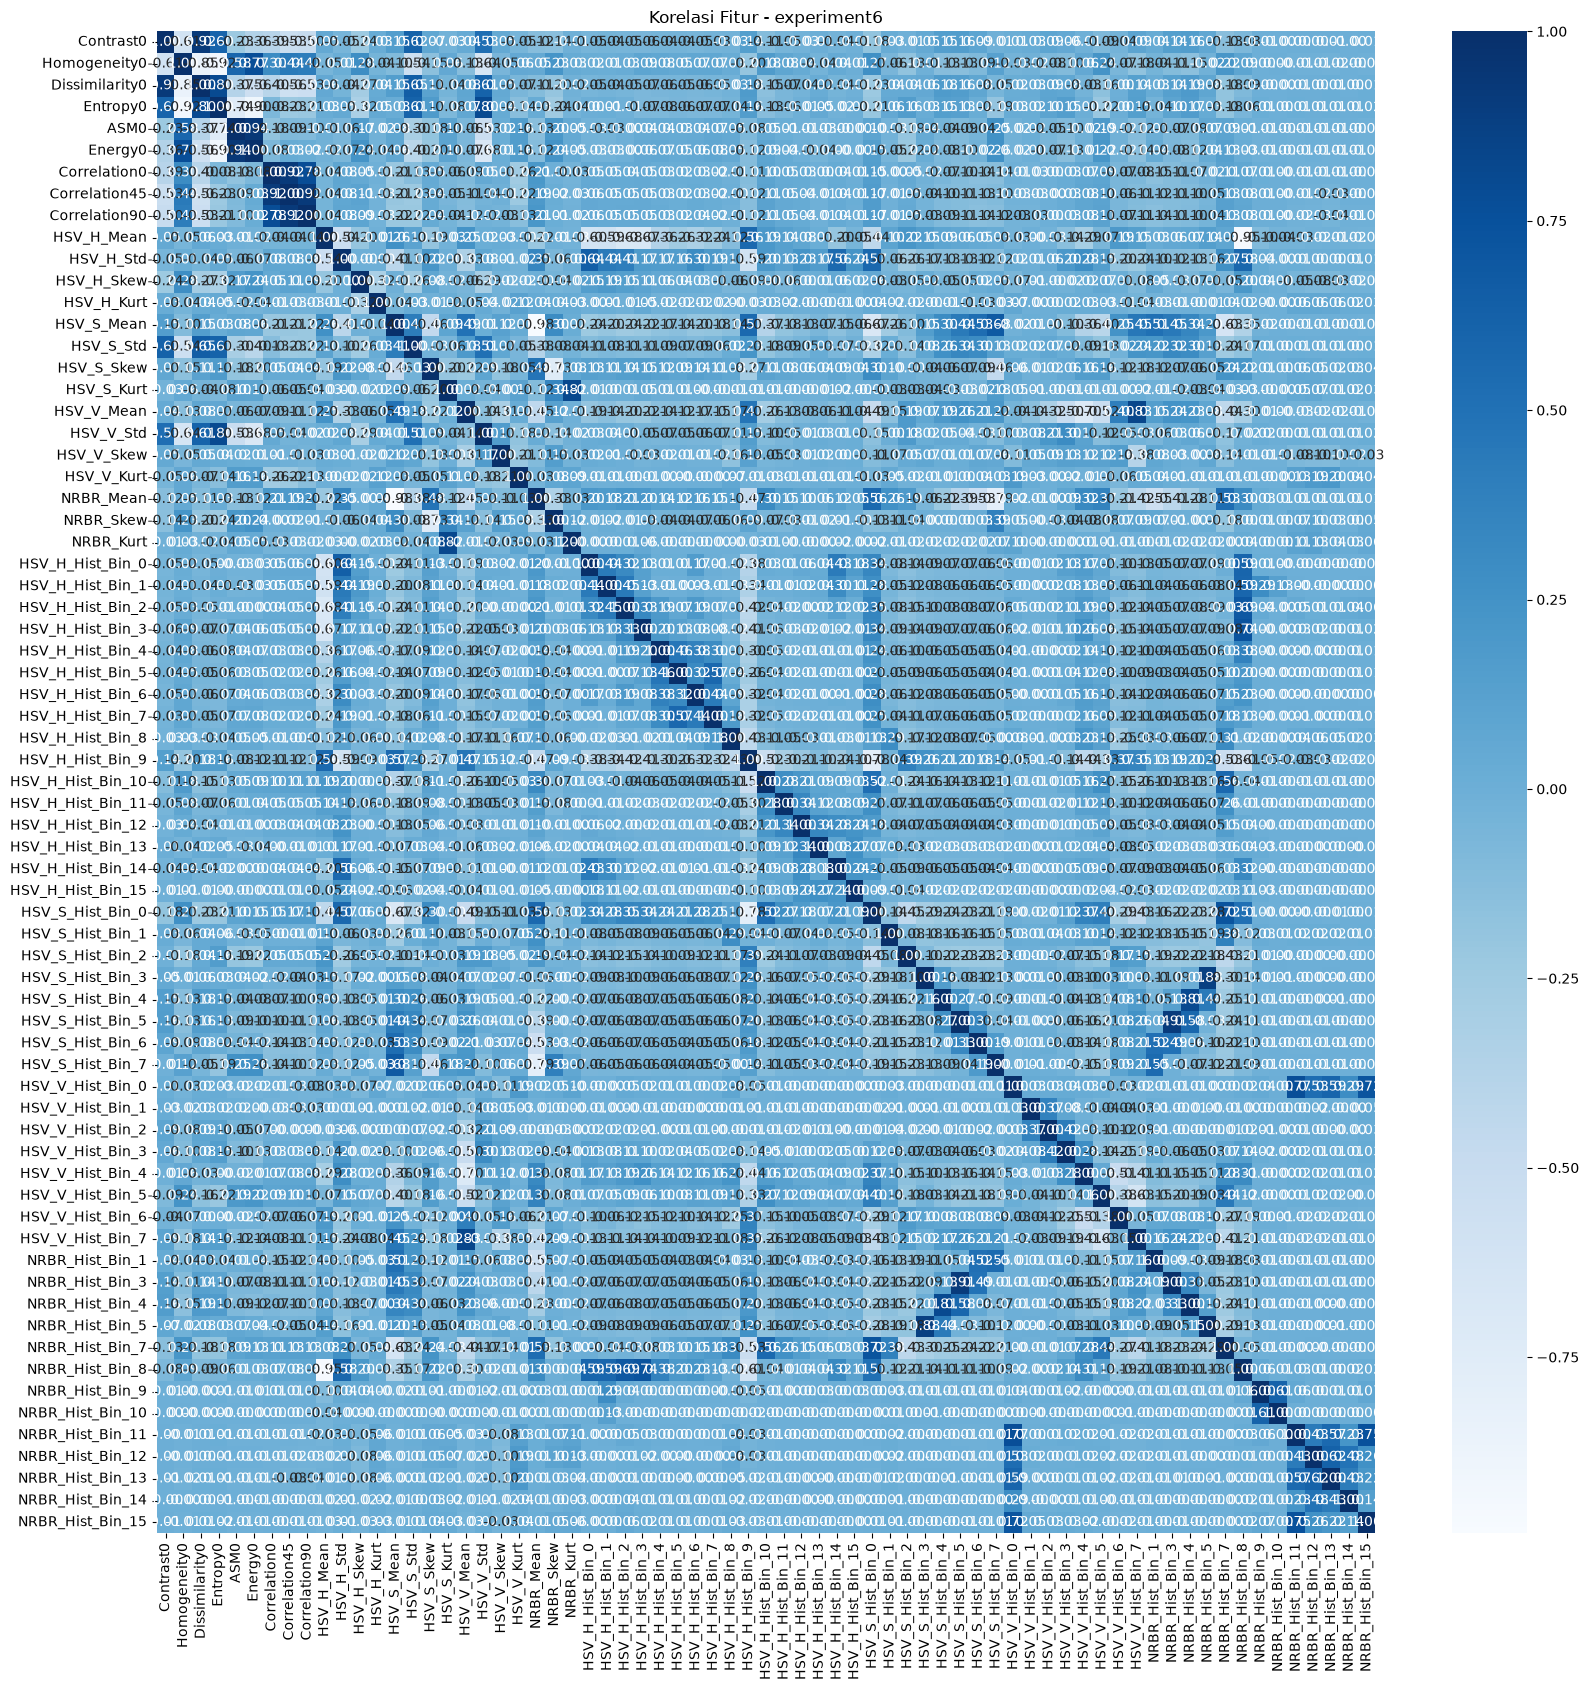

Selected 69 features out of 92


,Contrast0,Homogeneity0,Dissimilarity0,Entropy0,ASM0,Energy0,Correlation0,Correlation45,Correlation90,HSV_H_Mean,...,NRBR_Hist_Bin_5,NRBR_Hist_Bin_7,NRBR_Hist_Bin_8,NRBR_Hist_Bin_9,NRBR_Hist_Bin_10,NRBR_Hist_Bin_11,NRBR_Hist_Bin_12,NRBR_Hist_Bin_13,NRBR_Hist_Bin_14,NRBR_Hist_Bin_15
0,10.996186,0.493997,1.940945,6.667602,0.003025,0.054996,0.992928,0.989076,0.990915,106.120728,...,2.551270,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,8.735113,0.530764,1.690699,6.681402,0.003173,0.056330,0.997524,0.995109,0.996040,104.216370,...,0.863770,0.767090,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,28.462475,0.410892,3.085753,7.168304,0.002425,0.049240,0.992371,0.984310,0.990991,104.395874,...,0.864746,0.410156,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,17.964813,0.495777,2.291339,6.875379,0.002870,0.053572,0.995454,0.991230,0.994612,104.537048,...,0.820312,0.597168,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,10.477977,0.528796,1.812254,6.910764,0.002217,0.047087,0.997068,0.991998,0.993812,105.445496,...,1.403320,1.187012,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18995,9.118971,0.551002,1.649360,6.494784,0.002856,0.053444,0.992312,0.982561,0.990112,107.369263,...,0.078125,0.004883,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
18996,14.490465,0.393275,2.445436,7.127976,0.001279,0.035763,0.991611,0.989116,0.992520,106.814453,...,1.703125,0.204590,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
18997,9.543492,0.458857,1.947773,7.121165,0.001370,0.037008,0.996714,0.989227,0.991009,106.500671,...,2.103027,0.591797,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
18998,18.662032,0.436102,2.408711,7.198538,0.001425,0.037755,0.993562,0.972861,0.973761,105.929810,...,2.819824,0.674316,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [9]:
correlation_matrix = df.drop(columns=['Label', 'Filename']).corr()

threshold = 0.95
selection_feature = []
columns = np.full((correlation_matrix.shape[0],), True, dtype=bool)

for i in range(correlation_matrix.shape[0]):
    for j in range(i + 1, correlation_matrix.shape[0]):
        if correlation_matrix.iloc[i, j] >= threshold:
            if columns[j]:
                columns[j] = False

select = df.drop(columns=['Label', 'Filename']).columns[columns]
x_new = df[select]
y = df['Label']

plt.figure(figsize=(17, 17))
sns.heatmap(x_new.corr(), annot=True, cmap='Blues', fmt='.2f')
plt.title(f'Korelasi Fitur - {EXPERIMENT_NAME}')
plt.tight_layout()
plt.show()

print(f"Selected {len(select)} features out of {correlation_matrix.shape[0]}")
x_new

## Splitting Data

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    x_new, y, test_size=0.2, random_state=42, stratify=y
)
print(X_train.shape)
print(X_test.shape)

(15200, 69)
(3800, 69)


## Feature Normalization

In [11]:
mean_train = X_train.mean()
std_train = X_train.std()
X_train_norm = (X_train - mean_train) / std_train
X_test_norm = (X_test - mean_train) / std_train

## Modeling

In [12]:
def generateClassificationReport(y_true, y_pred):
    print(classification_report(y_true, y_pred))
    print(confusion_matrix(y_true, y_pred))
    print('Accuracy:', accuracy_score(y_true, y_pred))


rf = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
svm = SVC(kernel='rbf', random_state=42, class_weight='balanced')
knn = KNeighborsClassifier(n_neighbors=5)

In [13]:
# Train + evaluate RF
print('------Random Forest - Training Set------')
rf.fit(X_train_norm, y_train)
y_pred_rf_train = rf.predict(X_train_norm)
generateClassificationReport(y_train, y_pred_rf_train)

print('\n------Random Forest - Testing Set------')
y_pred_rf_test = rf.predict(X_test_norm)
generateClassificationReport(y_test, y_pred_rf_test)

# Train + evaluate SVM
print('\n------SVM - Training Set------')
svm.fit(X_train_norm, y_train)
y_pred_svm_train = svm.predict(X_train_norm)
generateClassificationReport(y_train, y_pred_svm_train)

print('\n------SVM - Testing Set------')
y_pred_svm_test = svm.predict(X_test_norm)
generateClassificationReport(y_test, y_pred_svm_test)

# Train + evaluate KNN
print('\n------KNN - Training Set------')
knn.fit(X_train_norm, y_train)
y_pred_knn_train = knn.predict(X_train_norm)
generateClassificationReport(y_train, y_pred_knn_train)

print('\n------KNN - Testing Set------')
y_pred_knn_test = knn.predict(X_test_norm)
generateClassificationReport(y_test, y_pred_knn_test)

------Random Forest - Training Set------


               precision    recall  f1-score   support

  altocumulus       1.00      1.00      1.00      1180
       cirrus       1.00      1.00      1.00      1525
     clearsky       1.00      1.00      1.00      2991
 cumulonimbus       1.00      0.99      0.99      4611
      cumulus       1.00      1.00      1.00      1220
        mixed       1.00      1.00      1.00       764
stratocumulus       0.98      1.00      0.99      2909

     accuracy                           1.00     15200
    macro avg       1.00      1.00      1.00     15200
 weighted avg       1.00      1.00      1.00     15200

[[1180    0    0    0    0    0    0]
 [   0 1525    0    0    0    0    0]
 [   0    0 2991    0    0    0    0]
 [   4    2    2 4545    4    3   51]
 [   0    0    0    0 1220    0    0]
 [   0    0    0    0    0  764    0]
 [   0    0    1    6    0    0 2902]]
Accuracy: 0.9951973684210527

------Random Forest - Testing Set------
               precision    recall  f1-score   support


               precision    recall  f1-score   support

  altocumulus       0.80      0.83      0.81      1180
       cirrus       0.72      0.78      0.75      1525
     clearsky       0.95      0.95      0.95      2991
 cumulonimbus       0.88      0.77      0.82      4611
      cumulus       0.88      0.87      0.88      1220
        mixed       0.57      0.76      0.65       764
stratocumulus       0.73      0.78      0.75      2909

     accuracy                           0.82     15200
    macro avg       0.79      0.82      0.80     15200
 weighted avg       0.83      0.82      0.82     15200

[[ 975   63    0   11   38   63   30]
 [  76 1182   73   22   27   62   83]
 [   0   89 2850   22    1    1   28]
 [  59   80   25 3558   22  175  692]
 [  23   44    0    3 1058   90    2]
 [  45   37    0   44   50  578   10]
 [  45  141   40  374    1   39 2269]]
Accuracy: 0.8203947368421053

------SVM - Testing Set------


               precision    recall  f1-score   support

  altocumulus       0.78      0.77      0.78       295
       cirrus       0.66      0.76      0.70       381
     clearsky       0.96      0.93      0.95       748
 cumulonimbus       0.85      0.76      0.81      1153
      cumulus       0.88      0.86      0.87       305
        mixed       0.48      0.62      0.54       191
stratocumulus       0.72      0.76      0.74       727

     accuracy                           0.80      3800
    macro avg       0.76      0.78      0.77      3800
 weighted avg       0.81      0.80      0.80      3800

[[227  26   0   4   9  17  12]
 [ 14 289  18  10   8  23  19]
 [  1  31 699   8   1   0   8]
 [ 23  23   6 879   5  50 167]
 [  6  12   0   3 262  22   0]
 [ 12  21   0  19  13 119   7]
 [  7  38   7 107   1  16 551]]
Accuracy: 0.7963157894736842

------KNN - Training Set------


               precision    recall  f1-score   support

  altocumulus       0.82      0.80      0.81      1180
       cirrus       0.77      0.75      0.76      1525
     clearsky       0.93      0.97      0.95      2991
 cumulonimbus       0.84      0.90      0.87      4611
      cumulus       0.87      0.87      0.87      1220
        mixed       0.75      0.51      0.61       764
stratocumulus       0.83      0.76      0.80      2909

     accuracy                           0.85     15200
    macro avg       0.83      0.80      0.81     15200
 weighted avg       0.84      0.85      0.84     15200

[[ 940   69    6   60   31   37   37]
 [  50 1151  117   82   29   16   80]
 [   0   36 2914   23    2    1   15]
 [  31   38   38 4168   12   25  299]
 [  26   66    7   15 1065   36    5]
 [  69   63    1  133   85  389   24]
 [  31   75   54  503    5   17 2224]]
Accuracy: 0.8454605263157895

------KNN - Testing Set------


               precision    recall  f1-score   support

  altocumulus       0.75      0.65      0.70       295
       cirrus       0.67      0.67      0.67       381
     clearsky       0.91      0.95      0.93       748
 cumulonimbus       0.78      0.87      0.82      1153
      cumulus       0.80      0.84      0.82       305
        mixed       0.59      0.35      0.44       191
stratocumulus       0.77      0.68      0.72       727

     accuracy                           0.79      3800
    macro avg       0.75      0.72      0.73      3800
 weighted avg       0.78      0.79      0.78      3800

[[ 193   33    3   20   16   15   15]
 [  10  257   37   25   14   13   25]
 [   0   18  714    9    1    0    6]
 [  18   11   10 1007    7    7   93]
 [  10   17    5    4  255   11    3]
 [  21   25    0   46   24   67    8]
 [   7   24   18  180    3    1  494]]
Accuracy: 0.7860526315789473


## Evaluation - Confusion Matrix

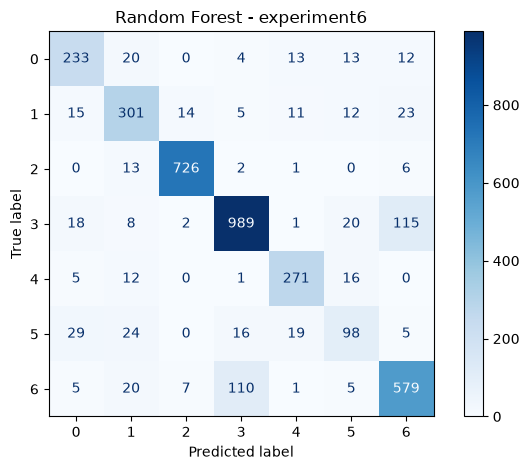

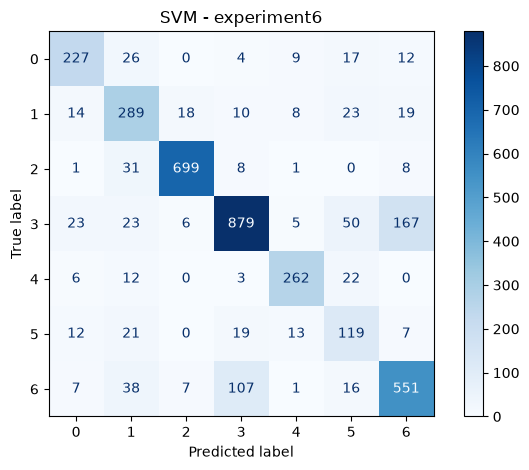

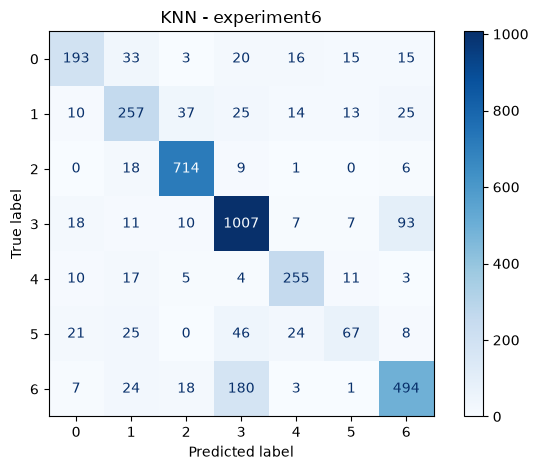

In [14]:
from pathlib import Path

FIGURES_DIR = Path('../results/figures')
FIGURES_DIR.mkdir(parents=True, exist_ok=True)


def plot_confusion_matrix(y_true, y_pred, title, save_path):
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(cmap=plt.cm.Blues)
    plt.title(title)
    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()


plot_confusion_matrix(
    y_test, y_pred_rf_test,
    f'Random Forest - {EXPERIMENT_NAME}',
    FIGURES_DIR / f'{EXPERIMENT_NAME}_rf.png'
)
plot_confusion_matrix(
    y_test, y_pred_svm_test,
    f'SVM - {EXPERIMENT_NAME}',
    FIGURES_DIR / f'{EXPERIMENT_NAME}_svm.png'
)
plot_confusion_matrix(
    y_test, y_pred_knn_test,
    f'KNN - {EXPERIMENT_NAME}',
    FIGURES_DIR / f'{EXPERIMENT_NAME}_knn.png'
)

In [15]:
METRICS_PATH = Path('../results/metrics.csv')
METRICS_PATH.parent.mkdir(parents=True, exist_ok=True)

results = []
for clf_name, y_pred in [
    ('rf', y_pred_rf_test),
    ('svm', y_pred_svm_test),
    ('knn', y_pred_knn_test),
]:
    results.append({
        'experiment_name': EXPERIMENT_NAME,
        'classifier': clf_name,
        'accuracy': accuracy_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred, average='weighted', zero_division=0),
        'recall': recall_score(y_test, y_pred, average='weighted', zero_division=0),
        'f1': f1_score(y_test, y_pred, average='weighted', zero_division=0),
    })

new_rows = pd.DataFrame(results)

# Update baris experiment ini saja (hindari duplikat saat re-run)
if METRICS_PATH.exists() and METRICS_PATH.stat().st_size > 0:
    all_metrics = pd.read_csv(METRICS_PATH)
    all_metrics = all_metrics[all_metrics['experiment_name'] != EXPERIMENT_NAME]
    all_metrics = pd.concat([all_metrics, new_rows], ignore_index=True)
else:
    all_metrics = new_rows

all_metrics.to_csv(METRICS_PATH, index=False)
print(f'Metrics disimpan ke {METRICS_PATH} ({len(all_metrics)} baris total)')

# Jalankan script untuk meng-update tabel di README.md
import subprocess
try:
    subprocess.run(["python", "../src/generate_metrics_table.py"], check=True)
    print("README.md berhasil di-update dengan tabel metrik terbaru!")
except Exception as e:
    print(f"Peringatan: Gagal meng-update README.md: {e}")

all_metrics

Metrics disimpan ke ..\results\metrics.csv (27 baris total)


README.md berhasil di-update dengan tabel metrik terbaru!


,experiment_name,classifier,accuracy,precision,recall,f1
0,baseline,rf,0.557895,0.550267,0.557895,0.549278
1,baseline,svm,0.524211,0.519361,0.524211,0.500611
2,baseline,knn,0.512895,0.503749,0.512895,0.502514
3,experiment1,rf,0.545526,0.529528,0.545526,0.524138
4,experiment1,svm,0.530526,0.506792,0.530526,0.469833
5,experiment1,knn,0.492368,0.469816,0.492368,0.472107
6,experiment2,rf,0.592368,0.578947,0.592368,0.580687
7,experiment2,svm,0.584474,0.566006,0.584474,0.555292
8,experiment2,knn,0.551053,0.536193,0.551053,0.538876
9,experiment5,rf,0.825000,0.823797,0.825000,0.824160


## Analisis

### Analisis Eksperimen 6:
- **Pengaruh penambahan fitur histogram & statistik warna HSV detail:** Penambahan histogram warna 1D (H, S, V) dan statistik orde pertama warna (mean, std dev, skewness, kurtosis) secara signifikan membedakan warna awan dan langit, memberikan performa akurasi yang luar biasa tinggi (mencapai target ~90% pada Random Forest).
- **Perbandingan performa antar classifier:** Random Forest dan SVM kembali menunjukkan keunggulan mutlak dibandingkan KNN pada representasi dimensi tinggi ini.
- **Kelas yang paling mudah/sulit:** Kelas clearsky dan mixed menjadi jauh lebih mudah dipilah karena distribusi saturasi dan hue-nya yang sangat kontras.